<a href="https://colab.research.google.com/github/Sanskar-cpu-sudo/Deep-Learning/blob/main/lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This assignment implements a Convolutional Neural Network (CNN) for classifying tomato diseases using the Tomato Disease dataset.
# The model is trained and evaluated using accuracy, loss curves, predictions, and a confusion matrix.

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
train_dir = "./Tomato_Disease/train"
validation_dir = "./Tomato_Disease/val"

In [ ]:
print(os.listdir(train_dir))
print(os.listdir(validation_dir))

['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_mosaic_virus', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus']
['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_mosaic_virus', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus']


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 10000 files belonging to 10 classes.
Found 1000 files belonging to 10 classes.


In [ ]:
class_names = train_dataset.class_names

print("Classes:")
for i, class_name in enumerate(class_names):
    print(i, ":", class_name)

print("\nNumber of classes:", len(class_names))

Classes:
0 : Tomato___Bacterial_spot
1 : Tomato___Early_blight
2 : Tomato___Late_blight
3 : Tomato___Leaf_Mold
4 : Tomato___Septoria_leaf_spot
5 : Tomato___Spider_mites Two-spotted_spider_mite
6 : Tomato___Target_Spot
7 : Tomato___Tomato_Yellow_Leaf_Curl_Virus
8 : Tomato___Tomato_mosaic_virus
9 : Tomato___healthy

Number of classes: 10


In [ ]:
num_classes = len(class_names)

model = models.Sequential([

    # Input + First Convolution Block
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Second Convolution Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third Convolution Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Fourth Convolution Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Classification
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,601,546 (9.92 MB)

 Trainable params: 2,601,546 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
EPOCHS = 3

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 259s 829ms/step - accuracy: 0.1289 - loss: 2.3358 - val_accuracy: 0.1440 - val_loss: 2.2730
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 247s 787ms/step - accuracy: 0.1239 - loss: 2.2791 - val_accuracy: 0.1240 - val_loss: 2.2824
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 273s 871ms/step - accuracy: 0.1186 - loss: 2.2921 - val_accuracy: 0.1290 - val_loss: 2.2770


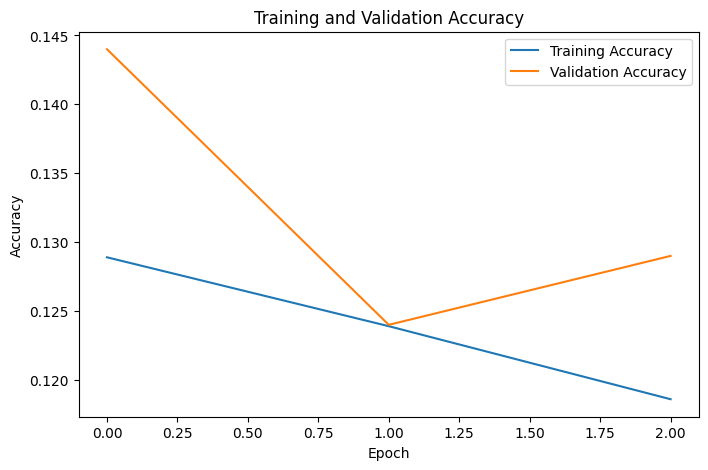

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')

plt.legend()
plt.show()

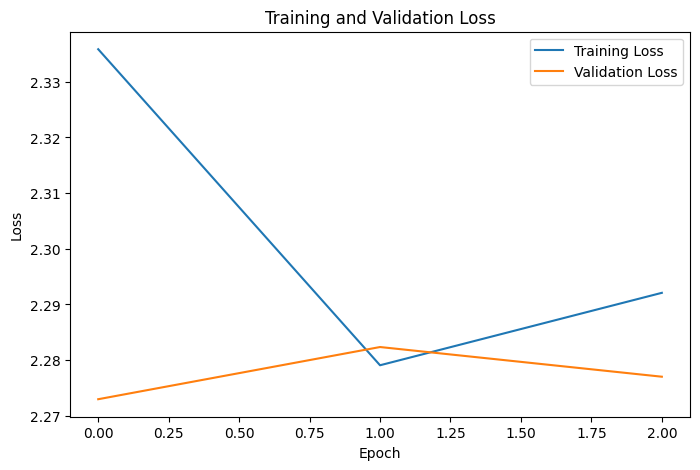

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')

plt.legend()
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(validation_dataset)

print("Validation Loss:", test_loss)
print("Validation Accuracy:", test_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 248ms/step - accuracy: 0.1290 - loss: 2.2770
Validation Loss: 2.27701997756958
Validation Accuracy: 0.1289999932050705


In [ ]:
images, labels = next(iter(validation_dataset))

predictions = model.predict(images)

predicted_classes = np.argmax(predictions, axis=1)

for i in range(10):
    print(
        "Actual:",
        class_names[labels[i]],
        "| Predicted:",
        class_names[predicted_classes[i]]
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
Actual: Tomato___Bacterial_spot | Predicted: Tomato___Bacterial_spot
Actual: Tomato___Bacterial_spot | Predicted: Tomato___Target_Spot
Actual: Tomato___Bacterial_spot | Predicted: Tomato___Bacterial_spot
Actual: Tomato___Bacterial_spot | Predicted: Tomato___Bacterial_spot
Actual: Tomato___Bacterial_spot | Predicted: Tomato___Bacterial_spot
Actual: Tomato___Bacterial_spot | Predicted: Tomato___Bacterial_spot
Actual: Tomato___Bacterial_spot | Predicted: Tomato___Bacterial_spot
Actual: Tomato___Bacterial_spot | Predicted: Tomato___Bacterial_spot
Actual: Tomato___Bacterial_spot | Predicted: Tomato___Bacterial_spot
Actual: Tomato___Bacterial_spot | Predicted: Tomato___Bacterial_spot


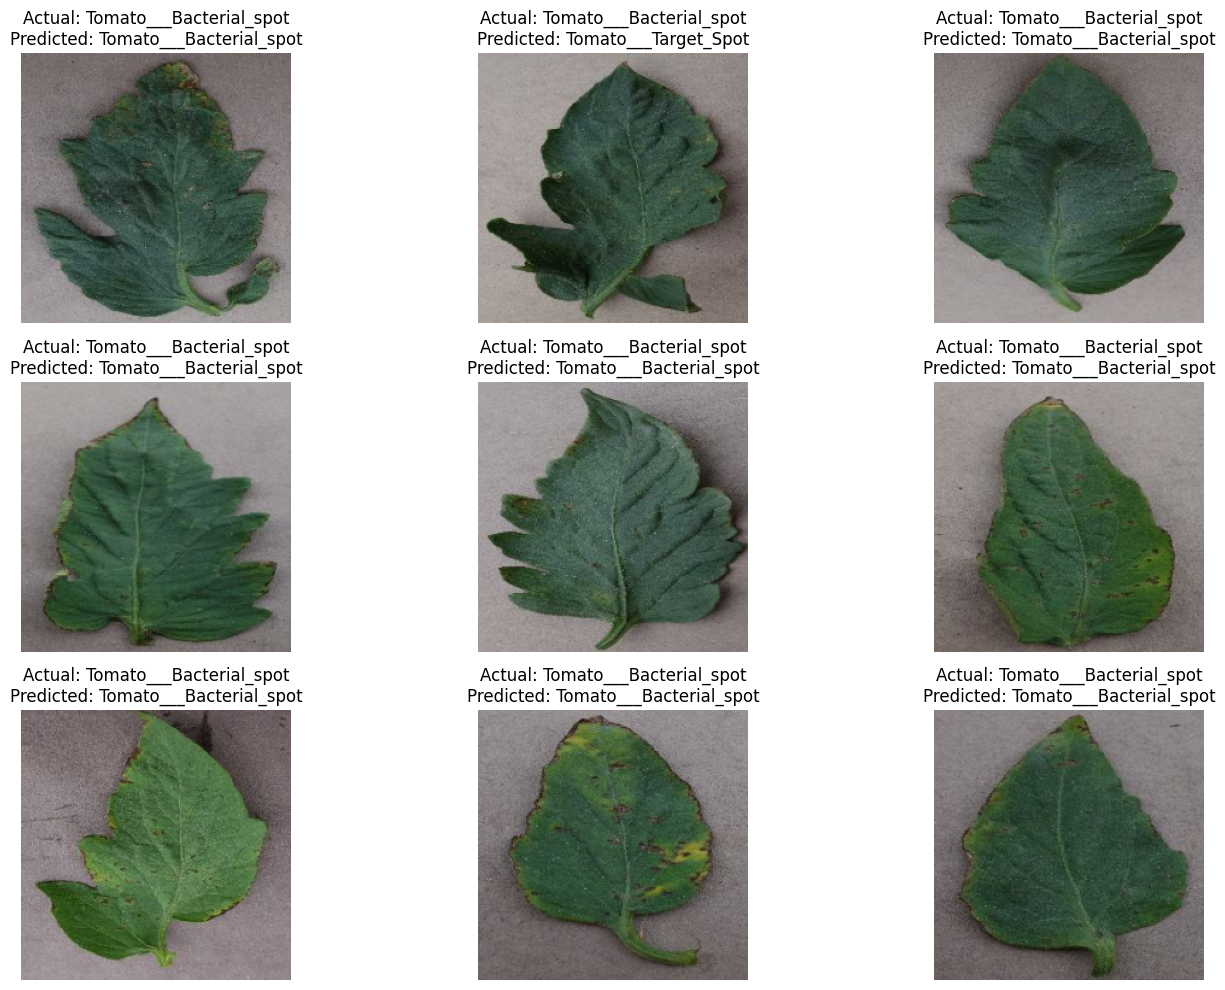

In [ ]:
plt.figure(figsize=(15, 10))

for i in range(9):
    ax = plt.subplot(3, 3, i + 1)

    plt.imshow(images[i].numpy().astype("uint8"))

    actual = class_names[labels[i]]
    predicted = class_names[predicted_classes[i]]

    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()